In [7]:
import os, string, calendar

import pandas as pd
import numpy as np
import itertools
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import ScaledTranslation

from pathlib import Path

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"] = "Avenir"

path_to_scenarios = '/Users/Guille/Desktop/india_power/scenarios'
path_to_images = '/Users/Guille/Desktop/india_power/images'
path_to_csvs = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_tables = '/Users/Guille/Desktop/india_power/tables'
path_to_inputs = '/Users/Guille/Desktop/india_power/input_data'
path_to_data = '/Users/Guille/Desktop/india_power/gridpath_india_viz/data/' 

In [86]:
# Grab data from databases for plotting energy dispatch and clean energy targets
def _load_dispatch(scen_labels_):

    # Load energy dispatch table and process data from database
    def __load_dispatch_from_csv(df_, scenario, zone):
        
        df_['power_mw'] = df_['number_of_hours_in_timepoint']*df_['timepoint_weight']*df_['power_mw']

        df_ = df_[['period', 
                   'timepoint',
                   'technology', 
                   'load_zone', 
                   'power_mw']]
            
        df_ = df_.groupby(['period', 
                           'timepoint',
                           'technology', 
                           'load_zone']).agg({'power_mw': 'sum'}).reset_index(drop = False)
        
        df_['scenario'] = scenario
                
        return df_
        
    # Load energy dispatch table and process data from database
    def __load_demand_from_csv(df_, scenario, zone):

        df_['static_load_mw']     = df_['number_of_hours_in_timepoint']*df_['timepoint_weight']*df_['static_load_mw']
        df_['overgeneration_mw']  = df_['number_of_hours_in_timepoint']*df_['timepoint_weight']*df_['overgeneration_mw']
        df_['unserved_energy_mw'] = df_['number_of_hours_in_timepoint']*df_['timepoint_weight']*df_['unserved_energy_mw']
        
        df_1_               = df_[['period', 'timepoint', 'load_zone', 'overgeneration_mw']].copy()
        df_1_['technology'] = 'Curtailment'                
        df_1_               = df_1_.rename(columns = {'overgeneration_mw': 'power_mw'})
        df_1_['power_mw'] = - df_1_['power_mw']
        
        df_2_               = df_[['period', 'timepoint','load_zone', 'unserved_energy_mw']].copy()
        df_2_['technology'] = 'Shedding'                 
        df_2_               = df_2_.rename(columns = {'unserved_energy_mw': 'power_mw'})

        df_3_               = df_[['period', 'timepoint','load_zone', 'static_load_mw']].copy()
        df_3_['technology'] = 'Load'                 
        df_3_               = df_3_.rename(columns = {'static_load_mw': 'power_mw'})

        
        df_ = pd.concat([df_1_, df_3_], axis = 0)
            
        df_ = df_.groupby(['period', 
                           'timepoint',
                           'technology', 
                           'load_zone']).agg({'power_mw': 'sum'}).reset_index(drop = False)
        
        df_['scenario'] = scenario
                                  
        return df_

    def __load_tx_losses_from_csv(df_, scenario, zone):
        
        df_['transmission_losses_lz_to']   = - df_['number_of_hours_in_timepoint']*df_['timepoint_weight']*df_['transmission_losses_lz_to'] 
        df_['transmission_losses_lz_from'] = - df_['number_of_hours_in_timepoint']*df_['timepoint_weight']*df_['transmission_losses_lz_from']

        df_1_               = df_[['period', 'timepoint', 'load_zone_to', 'transmission_losses_lz_to']].copy()
        df_1_['technology'] = 'Transmission Losses'
        df_1_               = df_1_.rename(columns = {'transmission_losses_lz_to': 'power_mw', 
                                                      'load_zone_to': 'load_zone'})

        df_2_               = df_[['period', 'timepoint','load_zone_from', 'transmission_losses_lz_from']].copy()
        df_2_['technology'] = 'Transmission Losses'
        df_2_               = df_2_.rename(columns = {'transmission_losses_lz_from': 'power_mw',
                                                      'load_zone_from': 'load_zone'})
        
        df_ = pd.concat([df_1_, df_2_], axis = 0)
        
        df_ = df_.groupby(['period', 
                           'timepoint',
                           'technology', 
                           'load_zone']).agg({'power_mw': 'sum'}).reset_index(drop = False)

        df_['scenario'] = scenario
        
        return df_

    dfs_ = []
    # Open connection: open database and grab meta-data
    for scenario, zone, path in zip(scen_labels_['scenario'], scen_labels_['zone'], scen_labels_['path']):
        print(scenario, zone, path)
        
        dir_name   = r'{}/{}'.format(path, scenario)
        dispatch_  = pd.read_csv(dir_name + f'/results/project_timepoint.csv', low_memory = False)
        demand_    = pd.read_csv(dir_name + f'/results/system_load_zone_timepoint.csv', low_memory = False)
        tx_losses_ = pd.read_csv(dir_name + f'/results/transmission_timepoint.csv', low_memory = False)
        
        dfs_ += [__load_tx_losses_from_csv(tx_losses_, scenario, zone)]
        dfs_ += [__load_demand_from_csv(demand_, scenario, zone)]
        dfs_ += [__load_dispatch_from_csv(dispatch_, scenario, zone)]

    return pd.concat(dfs_, axis = 0).reset_index(drop = True)
        
def _group_dispatch_technologies(dispatch_, tech_labels_):

    for group in tech_labels_['group'].unique():
        dispatch_.loc[dispatch_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    dispatch_ = dispatch_.groupby(['period', 
                                   'timepoint',
                                   'technology', 
                                   'load_zone', 
                                   'scenario']).agg('sum')

    return dispatch_.reset_index(drop = False)

In [87]:
scen_labels_ = pd.read_csv(path_to_csvs + '/pcm-scenario_labels.csv') 
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
zone_labels_ = pd.read_csv(path_to_csvs + '/zone_labels.csv') 
print(scen_labels_)

  zone                                           scenario  \
0  all  PC2030_1prob_VRElow_STlow_CONVmid_RES_H2_8PRM_...   
1  all  PC2040_1prob_VRElow_STlow_CONVmid_RES_H2_8PRM_...   
2  all  PC2050_1prob_VRElow_STlow_CONVmid_RES_H2_8PRM_...   
3  all  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...   
4  all  PC2040_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...   
5  all  PC2050_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...   
6  all  PC2030_1prob_VREhigh_SThigh_CONVmid_RES_H2_8PR...   
7  all  PC2040_1prob_VREhigh_SThigh_CONVmid_RES_H2_8PR...   
8  all  PC2050_1prob_VREhigh_SThigh_CONVmid_RES_H2_8PR...   

                               label    color linestyle  linewidth  order  \
0   VRE & ESS (low) Coal (low) - REF  #92918b     solid          3     10   
1   VRE & ESS (low) Coal (low) - REF  #92918b     solid          3     10   
2   VRE & ESS (low) Coal (low) - REF  #92918b     solid          3     10   
3   VRE & ESS (mid) Coal (low) - REF  #ca8250     solid          3     10   
4   

In [88]:
dispatch_ = _load_dispatch(scen_labels_)
grouped_dispatch_ = _group_dispatch_technologies(dispatch_, tech_labels_)


grouped_dispatch_['timepoint'] = grouped_dispatch_['timepoint'].astype(str)
grouped_dispatch_['month'] = grouped_dispatch_['timepoint'].str[4:6].astype(int)

monthly_grouped_dispatch_ = grouped_dispatch_.groupby(['technology', 
                                                       'scenario', 
                                                       'period',
                                                       'month']).agg({'power_mw': 'sum'}).reset_index(drop = False)

PC2030_1prob_VRElow_STlow_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pcm
PC2040_1prob_VRElow_STlow_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pcm
PC2050_1prob_VRElow_STlow_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pcm
PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pcm
PC2040_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pcm
PC2050_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pcm
PC2030_1prob_VREhigh_SThigh_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup all /Users/Guil

   technology                                           scenario  period  \
0        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
1        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
2        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
3        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
4        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
5        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
6        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
7        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
8        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
9        Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
10       Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   
11       Load  PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_...    2030   

    month  

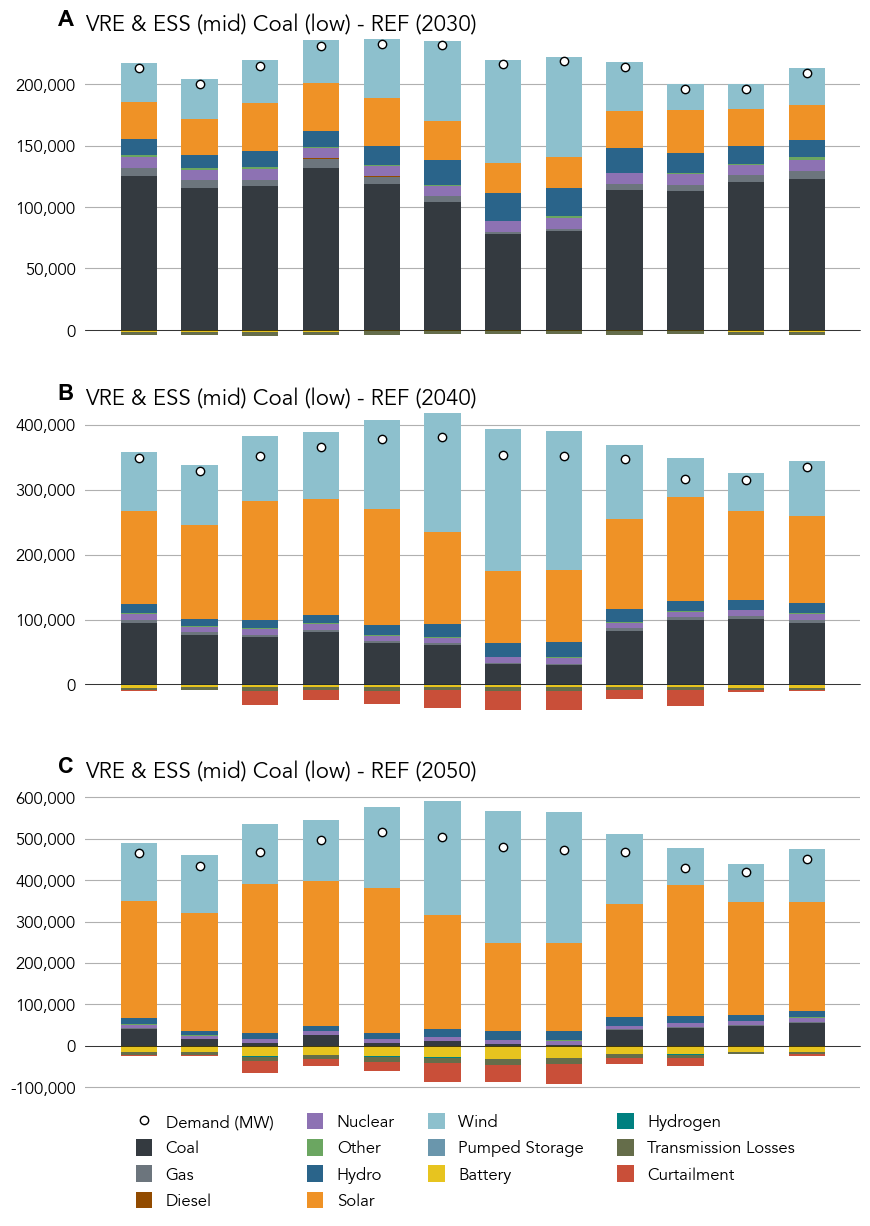

In [89]:
def _plot_monthly_generation(ax, df_, tech_labels_, scen_labels_, scenario, 
                             title = '', 
                             units = 1e3):
    
    df_p_ = df_.copy()
    df_p_ = df_p_.loc[df_p_['scenario'] == scenario].reset_index(drop = True)
    
    width = 0.6

    y_offset_positive_ = np.zeros(12)
    y_offset_negative_ = np.zeros(12)
    for technology in tech_labels_.sort_values(by='order')['group'].unique():

        idx_ = df_p_['technology'] == technology
        x_ = df_p_.loc[idx_, 'month'].to_numpy()
        y_ = df_p_.loc[idx_, 'power_mw'].to_numpy()

        idx_x_ = np.argsort(x_)
        color = tech_labels_.loc[tech_labels_['group'] == technology, 'group_color'].unique()[0]
        #print(technology, color, y_.shape, x_.shape)
        if y_.shape[0] == 12:
            if y_.sum() < 0:
                ax.bar(x_[idx_x_], y_[idx_x_]/units, width, 
                       bottom = y_offset_positive_/units,
                       color = color,
                       zorder = 2,
                       label = technology,
                       ec = 'None',
                       lw = 0.)
    
                y_offset_positive_ += y_[idx_x_]
    
            else:
                ax.bar(x_[idx_x_], y_[idx_x_]/units, width, 
                       bottom = y_offset_negative_/units,
                       color = color,
                       zorder = 2,
                       label = technology,
                       ec = 'None',
                       lw = 0.)
                
                y_offset_negative_ += y_[idx_x_]
        else:
            continue
            
    x_label_ = np.array([calendar.month_abbr[x] for x in x_])

    df_pp_ = df_p_.loc[df_p_['technology'] == 'Load'].reset_index(drop = True)
    print(df_pp_)

    x_ = df_pp_['month'].to_numpy()
    y_ = df_pp_['power_mw'].to_numpy()

    ax.plot(x_, y_/units, 
            linestyle = 'None',
            marker = 'o', 
            c = 'white', 
            label = 'Demand (MW)',
            zorder = 6,
            markeredgecolor = 'k')

    ax.set_xticks(x_, x_label_)

    ax.axhline(0, linewidth = .5, 
                  linestyle = '-', 
                  color = 'k', 
                  clip_on = False, 
                  zorder = 10)
    
    ax.xaxis.set_tick_params(labelsize = 14, left = False)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.set_title(title, fontsize = 16, loc = 'left')

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.grid(axis = 'y')

    
fig, _ax = plt.subplot_mosaic([['A'], ['B'], ['C']], 
                              figsize = (10, 13.75), 
                              gridspec_kw = {'height_ratios': [1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 16, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

_plot_monthly_generation(_ax['A'], monthly_grouped_dispatch_, tech_labels_, scen_labels_, 
                         title = 'VRE & ESS (mid) Coal (low) - REF (2030)',
                         scenario = 'PC2030_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup')

_plot_monthly_generation(_ax['B'], monthly_grouped_dispatch_, tech_labels_, scen_labels_, 
                         title = 'VRE & ESS (mid) Coal (low) - REF (2040)',
                         scenario = 'PC2040_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup')

_plot_monthly_generation(_ax['C'], monthly_grouped_dispatch_, tech_labels_, scen_labels_, 
                         title = 'VRE & ESS (mid) Coal (low) - REF (2050)',
                         scenario = 'PC2050_1prob_VREmid_STmid_CONVmid_RES_H2_8PRM_CC_50RPS_90CAP_500GW_PIERmid_startup')

ax.legend(#loc = 'upper right',
          bbox_to_anchor = (.935, 0.),
          frameon = False,
          ncol = 4,
          prop = {'size': 12})

plt.savefig(path_to_images + '/pcm-generation.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/pcm-generation.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()